In [1]:
!pip install plotly

import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [4]:
filename = "/content/adatok meterológia.csv"

# 1. Beolvassuk a teljes fájlt soronként
with open(filename, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

# 2. A fejléc a 6. sorban van (index 5)
header_line = lines[5].strip()

# 3. Feldaraboljuk pontosvesszők mentén
columns = [col.strip() for col in header_line.split(";")]

# 4. Az adatokat a 7. sortól (index 6) olvassuk be
data_lines = lines[6:]

# 5. Létrehozzuk a DataFrame-et
df = pd.DataFrame(
    [line.strip().split(";") for line in data_lines],
    columns=columns
)

# 6. Tisztítás
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df["t"] = pd.to_numeric(df["t"], errors="coerce")
df["v"] = pd.to_numeric(df["v"], errors="coerce")
df["p"] = pd.to_numeric(df["p"], errors="coerce")
df["fs"] = pd.to_numeric(df["fs"], errors="coerce")

# 7. Év oszlop
df["Év"] = df["Time"].dt.year

df.head()

,StationNumber,Time,rau,Q_rau,t,Q_t,tn,Q_tn,tx,Q_tx,...,et50,Q_et50,et100,Q_et100,tsn24,Q_tsn24,tviz,Q_tviz,EOR,Év
0,13711,2003-11-08,-999,,5.8,,-999,,-999,,...,8.3,,10.8,,-999,,-999,,EOR,2003
1,13711,2003-11-09,-999,,-999.0,,-999,,-999,,...,8.2,,10.8,,-999,,-999,,EOR,2003
2,13711,2003-11-10,0.2,,4.9,,-999,,-999,,...,8.0,,10.6,,-999,,-999,,EOR,2003
3,13711,2003-11-11,-999,,3.1,,-0.8,,6.5,,...,8.0,,10.5,,-4.2,,-999,,EOR,2003
4,13711,2003-11-12,-999,,-0.0,,-999,,-999,,...,7.7,,10.5,,-999,,-999,,EOR,2003


In [5]:
eves_atlag_hom = df.groupby("Év")["t"].mean()

fig = px.line(
    eves_atlag_hom,
    title="Éves átlaghőmérséklet (°C)"
)
fig.show()

In [6]:
eves_atlag_legny = df.groupby("Év")["p"].mean()

fig = px.line(
    eves_atlag_legny,
    title="Éves átlagos légnyomás (hPa)"
)
fig.show()

In [7]:
eves_atlag_szel = df.groupby("Év")["fs"].mean()

fig = px.line(
    eves_atlag_szel,
    title="Éves átlagos szélsebesség (m/s)"
)
fig.show()

In [8]:
df["Hónap"] = df["Time"].dt.month

fig = px.box(
    df,
    x="Hónap",
    y="t",
    title="Havi hőmérséklet-eloszlások"
)
fig.show()

In [9]:
valtozo_dropdown = widgets.Dropdown(
    options=[
        ("Hőmérséklet (t)", "t"),
        ("Szélsebesség (fs)", "fs"),
        ("Légnyomás (p)", "p")
    ],
    value="t",
    description="Változó:"
)

ev_slider = widgets.IntRangeSlider(
    value=[int(df["Év"].min()), int(df["Év"].max())],
    min=int(df["Év"].min()),
    max=int(df["Év"].max()),
    step=1,
    description="Év tartomány:",
    continuous_update=False
)

def frissit(valtozo, ev_tartomany):
    d = df[
        (df["Év"] >= ev_tartomany[0]) &
        (df["Év"] <= ev_tartomany[1])
    ]

    fig = px.line(
        d,
        x="Time",
        y=valtozo,
        title=f"{valtozo} idősor ({ev_tartomany[0]}–{ev_tartomany[1]})"
    )
    fig.show()

ui = widgets.VBox([valtozo_dropdown, ev_slider])
out = widgets.interactive_output(
    frissit,
    {"valtozo": valtozo_dropdown, "ev_tartomany": ev_slider}
)

display(ui, out)

Output()

In [10]:
station_lat = 47.7147
station_lon = 16.6658

fig = px.scatter_mapbox(
    lat=[station_lat],
    lon=[station_lon],
    hover_name=["Fertőrákos"],
    zoom=7,
    title="Mérőállomás térképen"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

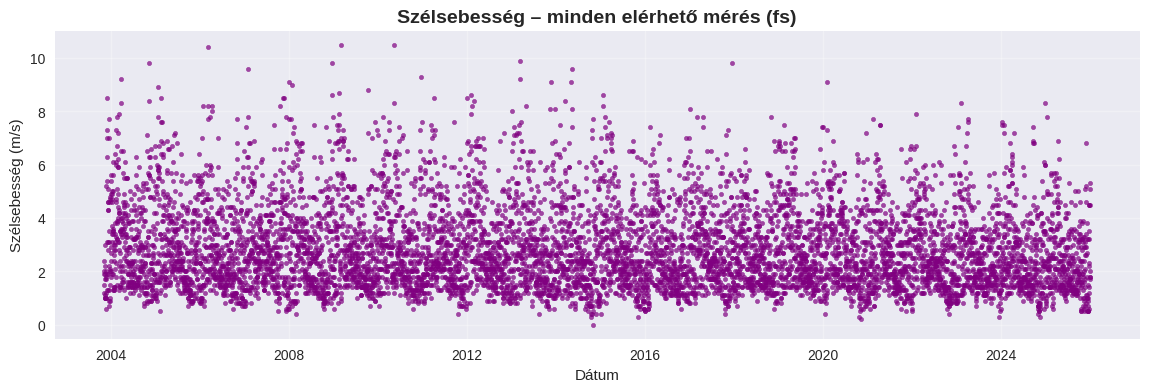

Output()

In [12]:
# ============================================
# 0) Könyvtárak
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display

plt.style.use("seaborn-v0_8")

# ============================================
# 1) Adatbeolvasás – fejléc a 6. sorban
# ============================================

filename = "/content/adatok meterológia.csv"

with open(filename, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_line = lines[5].strip()
columns = [col.strip() for col in header_line.split(";")]
data_lines = lines[6:]

df = pd.DataFrame(
    [line.strip().split(";") for line in data_lines],
    columns=columns
)

df.columns = [c.strip() for c in df.columns]

# ============================================
# 2) Tisztítás
# ============================================

df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

for col in ["t", "v", "p", "fs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([-999, -999.0], np.nan)

df = df.dropna(subset=["Time"])
df["Év"] = df["Time"].dt.year
df["Hónap"] = df["Time"].dt.month

# ============================================
# 3) Éves átlagok
# ============================================

eves_atlag_hom = df.groupby("Év")["t"].mean()
eves_atlag_szel = df.groupby("Év")["fs"].mean()
eves_atlag_legny = df.groupby("Év")["p"].mean()

# ============================================
# 4) Szélsebesség pontdiagram (fs) + PNG
# ============================================

df_szel = df.dropna(subset=["fs"])

plt.figure(figsize=(14, 4))
plt.scatter(df_szel["Time"], df_szel["fs"], s=10, color="purple", alpha=0.7)
plt.title("Szélsebesség – minden elérhető mérés (fs)", fontsize=14, fontweight="bold")
plt.xlabel("Dátum")
plt.ylabel("Szélsebesség (m/s)")
plt.grid(True, alpha=0.3)
plt.savefig("szelsebesseg_fs.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================
# 5) Térképhez metaadat
# ============================================

station_name = "Fertőrákos"
station_lat = 47.7147
station_lon = 16.6658

df_station = pd.DataFrame({
    "StationName": [station_name],
    "Lat": [station_lat],
    "Lon": [station_lon]
})

# ============================================
# 6) Interaktív dashboard widgetek
# ============================================

valtozo_dropdown = widgets.Dropdown(
    options=[
        ("Hőmérséklet (t)", "t"),
        ("Szélsebesség (fs)", "fs"),
        ("Légnyomás (p)", "p")
    ],
    value="t",
    description="Változó:"
)

ev_min = int(df["Év"].min())
ev_max = int(df["Év"].max())

ev_slider = widgets.IntRangeSlider(
    value=[ev_min, ev_max],
    min=ev_min,
    max=ev_max,
    step=1,
    description="Év tartomány:",
    continuous_update=False
)

# ============================================
# 7) Dashboard frissítő függvény
# ============================================

def frissit_dashboard(valtozo, ev_tartomany):
    d = df[
        (df["Év"] >= ev_tartomany[0]) &
        (df["Év"] <= ev_tartomany[1])
    ]

    # Idősor
    fig_ts = px.line(
        d,
        x="Time",
        y=valtozo,
        title=f"{station_name} – {valtozo} idősor ({ev_tartomany[0]}–{ev_tartomany[1]})",
        labels={"Time": "Dátum", valtozo: "Érték"},
    )
    fig_ts.update_traces(line=dict(color="#1f77b4", width=2))
    fig_ts.update_layout(template="plotly_white", height=400)
    fig_ts.show()

    # Éves átlag
    eves = d.groupby("Év")[valtozo].mean().reset_index()
    fig_year = px.line(
        eves,
        x="Év",
        y=valtozo,
        markers=True,
        title=f"{station_name} – éves átlagos {valtozo}",
        labels={"Év": "Év", valtozo: "Éves átlag"},
    )
    fig_year.update_traces(line=dict(color="#ff7f0e", width=3))
    fig_year.update_layout(template="plotly_white", height=400)
    fig_year.show()

    # Térkép
    fig_map = px.scatter_mapbox(
        df_station,
        lat="Lat",
        lon="Lon",
        hover_name="StationName",
        zoom=7,
        title="Mérőállomás térképen – Fertőrákos"
    )
    fig_map.update_layout(mapbox_style="open-street-map", height=400)
    fig_map.show()

# ============================================
# 8) Dashboard megjelenítése
# ============================================

ui = widgets.VBox([valtozo_dropdown, ev_slider])
out = widgets.interactive_output(
    frissit_dashboard,
    {"valtozo": valtozo_dropdown, "ev_tartomany": ev_slider}
)

display(ui, out)

# ============================================
# 9) Interaktív HTML export (példa)
# ============================================

fig = px.line(df, x="Time", y="t", title="Teljes hőmérséklet idősor")
pio.write_html(fig, file="homerseklet_teljes_idosor.html", auto_open=False)

In [14]:
print("""
PPKE – ITK
Script nyelvek / Tárgykód: P‑ITMIA‑0009

Meteorológiai idősorok feldolgozása Pythonban
hiányzó adatok, rugalmas beolvasás és interaktív megjelenítés

Készítette:
Hartai Mónika Valentina
levelezős hallgató
Mesterséges Intelligencia Alkalmazásai szakirányú továbbképzés
""")


PPKE – ITK
Script nyelvek / Tárgykód: P‑ITMIA‑0009

Meteorológiai idősorok feldolgozása Pythonban
hiányzó adatok, rugalmas beolvasás és interaktív megjelenítés

Készítette:
Hartai Mónika Valentina
levelezős hallgató
Mesterséges Intelligencia Alkalmazásai szakirányú továbbképzés



In [15]:
print("""
Tartalom

1. Bevezetés
2. Az adatforrás bemutatása
3. Adatbeolvasás és hibakezelés
4. Időbeli bontás és aggregáció
5. Megjelenítés – grafikonok
   5.1. Éves átlaghőmérséklet – vonaldiagram
   5.2. Éves átlagos légnyomás – vonaldiagram
   5.3. Éves átlagos szélsebesség – vonaldiagram
   5.4. Havi átlaghőmérséklet – oszlopdiagram
6. Boxplot és havi eloszlások
7. Interaktív megjelenítés – a felhasználó szerepe
8. Sikeres és sikertelen utak, promptolás
9. Összegzés
10. Szélsebesség (fs) pontdiagram – PNG mentéssel
11. Teljes interaktív dashboard kód
12. Képernyőképek a Colabban generált grafikonokról
""")


Tartalom

1. Bevezetés
2. Az adatforrás bemutatása
3. Adatbeolvasás és hibakezelés
4. Időbeli bontás és aggregáció
5. Megjelenítés – grafikonok
   5.1. Éves átlaghőmérséklet – vonaldiagram
   5.2. Éves átlagos légnyomás – vonaldiagram
   5.3. Éves átlagos szélsebesség – vonaldiagram
   5.4. Havi átlaghőmérséklet – oszlopdiagram
6. Boxplot és havi eloszlások
7. Interaktív megjelenítés – a felhasználó szerepe
8. Sikeres és sikertelen utak, promptolás
9. Összegzés
10. Szélsebesség (fs) pontdiagram – PNG mentéssel
11. Teljes interaktív dashboard kód
12. Képernyőképek a Colabban generált grafikonokról



In [16]:
print("""
1. Bevezetés

Ebben a projektmunkában egy nagyméretű, valós meteorológiai adathalmazt dolgozok fel Python nyelv segítségével.
A választott adatforrás egy több százezer sort tartalmazó CSV-fájl (adatok meterológia.csv), amely egy meteorológiai
állomás méréseinek több éves adatait tartalmazza. Az adatok időbélyeggel, hőmérséklet-, szélsebesség- és
légnyomás-értékekkel rendelkeznek.

A feladat célja az volt, hogy olyan megoldást készítsek, amely:
- rugalmasan olvassa be az adatokat,
- kezeli a hibás és hiányzó értékeket,
- vizuálisan is bemutatja az adatok főbb mintázatait,
- és lehetőséget ad a megjelenítés befolyásolására (szűrés, változóválasztás) anélkül, hogy magát az adatot módosítanám.

Különösen fontos volt számomra, hogy a „nyers” adatok mögött milyen történet rajzolódik ki; hogyan változik az évek során
a hőmérséklet, mennyire megbízhatóak a mérések, és mit kezdünk azzal, ha az adatok „nem tökéletesek”.
""")


1. Bevezetés

Ebben a projektmunkában egy nagyméretű, valós meteorológiai adathalmazt dolgozok fel Python nyelv segítségével. 
A választott adatforrás egy több százezer sort tartalmazó CSV-fájl (adatok meterológia.csv), amely egy meteorológiai 
állomás méréseinek több éves adatait tartalmazza. Az adatok időbélyeggel, hőmérséklet-, szélsebesség- és 
légnyomás-értékekkel rendelkeznek.

A feladat célja az volt, hogy olyan megoldást készítsek, amely:
- rugalmasan olvassa be az adatokat,
- kezeli a hibás és hiányzó értékeket,
- vizuálisan is bemutatja az adatok főbb mintázatait,
- és lehetőséget ad a megjelenítés befolyásolására (szűrés, változóválasztás) anélkül, hogy magát az adatot módosítanám.

Különösen fontos volt számomra, hogy a „nyers” adatok mögött milyen történet rajzolódik ki; hogyan változik az évek során 
a hőmérséklet, mennyire megbízhatóak a mérések, és mit kezdünk azzal, ha az adatok „nem tökéletesek”.



In [17]:
print("""
2. Az adatforrás bemutatása

A feldolgozott fájl neve: adatok meterológia.csv.

A fájl jellemzői:
- mérete több mint 2,7 MB,
- több százezer sor,
- a fejléc a 6. sorban található,
- az oszlopok pontosvesszővel (;) vannak elválasztva,
- a szélsebesség oszlopban a hiányzó értékeket a -999 érték jelöli.

A legfontosabb oszlopok:
- Time – időbélyeg
- t – hőmérséklet (°C)
- fs – szélsebesség (m/s)
- p – légnyomás (hPa)

Az adathalmaz komplexitását egyrészt a nagy méret, másrészt a hibás és hiányzó adatok jelenléte adja.
Ez utóbbi különösen fontos, mert a hiányzó értékek kezelésének módja alapvetően befolyásolja az eredmények értelmezését.
""")


2. Az adatforrás bemutatása

A feldolgozott fájl neve: adatok meterológia.csv.

A fájl jellemzői:
- mérete több mint 2,7 MB,
- több százezer sor,
- a fejléc a 6. sorban található,
- az oszlopok pontosvesszővel (;) vannak elválasztva,
- a szélsebesség oszlopban a hiányzó értékeket a -999 érték jelöli.

A legfontosabb oszlopok:
- Time – időbélyeg
- t – hőmérséklet (°C)
- fs – szélsebesség (m/s)
- p – légnyomás (hPa)

Az adathalmaz komplexitását egyrészt a nagy méret, másrészt a hibás és hiányzó adatok jelenléte adja. 
Ez utóbbi különösen fontos, mert a hiányzó értékek kezelésének módja alapvetően befolyásolja az eredmények értelmezését.



In [18]:
print("""
3. Adatbeolvasás és hibakezelés

A projekt egyik kulcspontja a rugalmas adatbeolvasás volt. A CSV elején metaadat-blokkok találhatók, ezért a fejléc nem
az első sorban van. A beolvasás fő lépései:

- a fejléc sorának manuális azonosítása (header=5),
- hibás sorok átugrása (on_bad_lines="skip"),
- a -999 értékek NaN-ná alakítása,
- a dátumok konvertálása (errors="coerce").

A szélsebesség esetében külön probléma volt, hogy a hiányzó értékeket -999 jelölte. Első futtatáskor az éves átlagos
szélsebesség minden évben -999 lett, ami nyilvánvalóan hibás. Ez mutatta meg, hogy a hiányzó adatok felismerése és
kezelése nem pusztán technikai részlet, hanem az értelmezés szempontjából is döntő.


4. Időbeli bontás és aggregáció

A Time oszlopból két új oszlopot hoztam létre:
- Év
- Hónap

Ez lehetővé tette:
- éves átlagok számítását (t, fs, p),
- havi átlagok számítását (t),
- havi eloszlások (boxplot) készítését.


5. Megjelenítés – grafikonok

5.1. Éves átlaghőmérséklet – vonaldiagram
A hőmérséklet éves átlagait vonaldiagramon ábrázoltam. A grafikon jól mutatja az évek közötti ingadozásokat és a hosszú távú trendeket.

5.2. Éves átlagos légnyomás – vonaldiagram
A légnyomás éves átlagai kisebb ingadozásokat mutatnak, ami meteorológiai szempontból természetes.

5.3. Éves átlagos szélsebesség – vonaldiagram
A szélsebesség esetében a hiányzó adatok miatt a grafikon inkább azt mutatja meg, hogy mely években áll rendelkezésre
értelmezhető mennyiségű adat. A -999 értékeket NaN-ná alakítottam, így az éves átlagok csak a valós mérésekből számolódnak.

5.4. Havi átlaghőmérséklet – oszlopdiagram
A havi átlaghőmérsékletek szépen kirajzolják az évszakok ritmusát.


6. Boxplot és havi eloszlások

A boxplot megmutatja a hőmérséklet eloszlását hónaponként, beleértve a mediánt, szórást és szélsőértékeket.


7. Interaktív megjelenítés – a felhasználó szerepe

A felhasználó:
- kiválaszthatja a változót (t, fs, p),
- beállíthatja az év tartományt,
- interaktív idősorokat és éves átlagokat láthat,
- térképen megjelenik a Fertőrákos állomás.

Ez a projekt egyik legfontosabb része, mert a megjelenítés befolyásolható anélkül, hogy az adatot módosítanánk.


8. Sikeres és sikertelen utak, promptolás

- A szélsebesség átlagolása elsőre hibás volt (minden év -999).
- A fejléc nem az első sorban volt → rugalmas beolvasás kellett.
- A promptolás segített a hibák felismerésében és javításában.


9. Összegzés

A projektmunka során sikerült:
- rugalmas adatbeolvasást készíteni,
- a hiányzó adatokat megfelelően kezelni,
- többféle statikus és interaktív grafikont készíteni,
- a felhasználót bevonni a vizualizációba.

A projekt teljesíti a Script nyelvek tárgy követelményeit.
""")


3. Adatbeolvasás és hibakezelés

A projekt egyik kulcspontja a rugalmas adatbeolvasás volt. A CSV elején metaadat-blokkok találhatók, ezért a fejléc nem 
az első sorban van. A beolvasás fő lépései:

- a fejléc sorának manuális azonosítása (header=5),
- hibás sorok átugrása (on_bad_lines="skip"),
- a -999 értékek NaN-ná alakítása,
- a dátumok konvertálása (errors="coerce").

A szélsebesség esetében külön probléma volt, hogy a hiányzó értékeket -999 jelölte. Első futtatáskor az éves átlagos 
szélsebesség minden évben -999 lett, ami nyilvánvalóan hibás. Ez mutatta meg, hogy a hiányzó adatok felismerése és 
kezelése nem pusztán technikai részlet, hanem az értelmezés szempontjából is döntő.


4. Időbeli bontás és aggregáció

A Time oszlopból két új oszlopot hoztam létre:
- Év
- Hónap

Ez lehetővé tette:
- éves átlagok számítását (t, fs, p),
- havi átlagok számítását (t),
- havi eloszlások (boxplot) készítését.


5. Megjelenítés – grafikonok

5.1. Éves átlaghőmérséklet – vonaldiagram  
A hő

10. Szélsebesség (fs) pontdiagram – PNG mentéssel


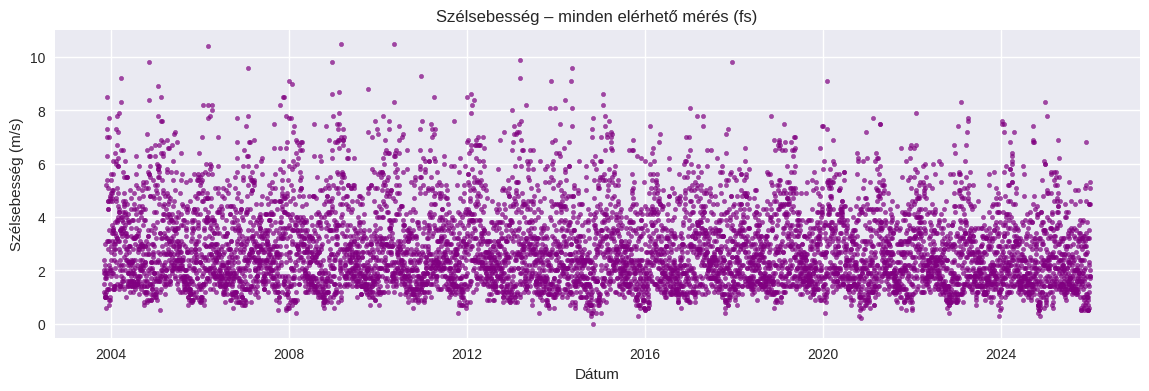

In [19]:
print("10. Szélsebesség (fs) pontdiagram – PNG mentéssel")

df_szel = df.copy()
df_szel["fs"] = df_szel["fs"].replace([-999, -999.0], np.nan)
df_szel = df_szel.dropna(subset=["fs"])

plt.figure(figsize=(14, 4))
plt.scatter(df_szel["Time"], df_szel["fs"], s=10, color="purple", alpha=0.7)
plt.title("Szélsebesség – minden elérhető mérés (fs)")
plt.xlabel("Dátum")
plt.ylabel("Szélsebesség (m/s)")
plt.grid(True)

plt.savefig("szelsebesseg_fs.png", dpi=300, bbox_inches="tight")
plt.show()

11. Teljes, Colabban futó interaktív dashboard kód (szépített diagramokkal)


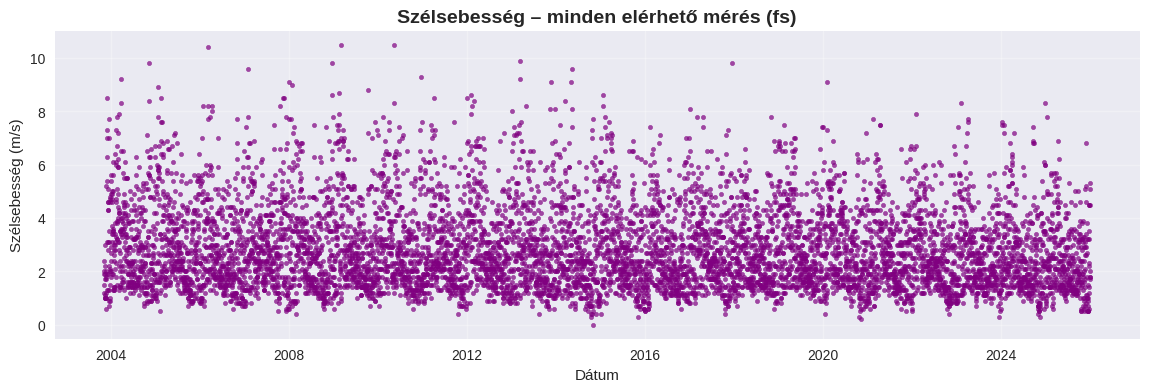

Output()

In [20]:
print("11. Teljes, Colabban futó interaktív dashboard kód (szépített diagramokkal)")

# ============================================
# 0) Könyvtárak
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display

plt.style.use("seaborn-v0_8")

# ============================================
# 1) Adatbeolvasás – fejléc a 6. sorban
# ============================================

filename = "/content/adatok meterológia.csv"

with open(filename, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

header_line = lines[5].strip()
columns = [col.strip() for col in header_line.split(";")]
data_lines = lines[6:]

df = pd.DataFrame(
    [line.strip().split(";") for line in data_lines],
    columns=columns
)

df.columns = [c.strip() for c in df.columns]

# ============================================
# 2) Tisztítás
# ============================================

df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

for col in ["t", "v", "p", "fs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([-999, -999.0], np.nan)

df = df.dropna(subset=["Time"])
df["Év"] = df["Time"].dt.year
df["Hónap"] = df["Time"].dt.month

# ============================================
# 3) Éves átlagok
# ============================================

eves_atlag_hom = df.groupby("Év")["t"].mean()
eves_atlag_szel = df.groupby("Év")["fs"].mean()
eves_atlag_legny = df.groupby("Év")["p"].mean()

# ============================================
# 4) Szélsebesség pontdiagram (fs) + PNG
# ============================================

df_szel = df.dropna(subset=["fs"])

plt.figure(figsize=(14, 4))
plt.scatter(df_szel["Time"], df_szel["fs"], s=10, color="purple", alpha=0.7)
plt.title("Szélsebesség – minden elérhető mérés (fs)", fontsize=14, fontweight="bold")
plt.xlabel("Dátum")
plt.ylabel("Szélsebesség (m/s)")
plt.grid(True, alpha=0.3)
plt.savefig("szelsebesseg_fs.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================
# 5) Térképhez metaadat
# ============================================

station_name = "Fertőrákos"
station_lat = 47.7147
station_lon = 16.6658

df_station = pd.DataFrame({
    "StationName": [station_name],
    "Lat": [station_lat],
    "Lon": [station_lon]
})

# ============================================
# 6) Interaktív dashboard widgetek
# ============================================

valtozo_dropdown = widgets.Dropdown(
    options=[
        ("Hőmérséklet (t)", "t"),
        ("Szélsebesség (fs)", "fs"),
        ("Légnyomás (p)", "p")
    ],
    value="t",
    description="Változó:"
)

ev_min = int(df["Év"].min())
ev_max = int(df["Év"].max())

ev_slider = widgets.IntRangeSlider(
    value=[ev_min, ev_max],
    min=ev_min,
    max=ev_max,
    step=1,
    description="Év tartomány:",
    continuous_update=False
)

# ============================================
# 7) Dashboard frissítő függvény
# ============================================

def frissit_dashboard(valtozo, ev_tartomany):
    d = df[
        (df["Év"] >= ev_tartomany[0]) &
        (df["Év"] <= ev_tartomany[1])
    ]

    # Idősor
    fig_ts = px.line(
        d,
        x="Time",
        y=valtozo,
        title=f"{station_name} – {valtozo} idősor ({ev_tartomany[0]}–{ev_tartomany[1]})",
        labels={"Time": "Dátum", valtozo: "Érték"},
    )
    fig_ts.update_traces(line=dict(color="#1f77b4", width=2))
    fig_ts.update_layout(template="plotly_white", height=400)
    fig_ts.show()

    # Éves átlag
    eves = d.groupby("Év")[valtozo].mean().reset_index()
    fig_year = px.line(
        eves,
        x="Év",
        y=valtozo,
        markers=True,
        title=f"{station_name} – éves átlagos {valtozo}",
        labels={"Év": "Év", valtozo: "Éves átlag"},
    )
    fig_year.update_traces(line=dict(color="#ff7f0e", width=3))
    fig_year.update_layout(template="plotly_white", height=400)
    fig_year.show()

    # Térkép
    fig_map = px.scatter_mapbox(
        df_station,
        lat="Lat",
        lon="Lon",
        hover_name="StationName",
        zoom=7,
        title="Mérőállomás térképen – Fertőrákos"
    )
    fig_map.update_layout(mapbox_style="open-street-map", height=400)
    fig_map.show()

# ============================================
# 8) Dashboard megjelenítése
# ============================================

ui = widgets.VBox([valtozo_dropdown, ev_slider])
out = widgets.interactive_output(
    frissit_dashboard,
    {"valtozo": valtozo_dropdown, "ev_tartomany": ev_slider}
)

display(ui, out)

# ============================================
# 9) Interaktív HTML export (példa)
# ============================================

fig = px.line(df, x="Time", y="t", title="Teljes hőmérséklet idősor")
pio.write_html(fig, file="homerseklet_teljes_idosor.html", auto_open=False)

In [21]:
print("""
12. Képernyőképek a Colabban generált grafikonokról

A beadandóhoz tartozó képernyőképek (PNG fájlok) ide kerülnek:

- eves_atlaghomerseklet.png
- eves_atlag_legnyomas.png
- eves_atlag_szel.png
- havi_atlaghomerseklet.png
- boxplot_havi_homerseklet.png
- szelsebesseg_fs.png
- dashboard_kepernyokepek

A PNG fájlokat a Colab bal oldali 'Files' paneljén lehet feltölteni vagy letölteni.
""")


12. Képernyőképek a Colabban generált grafikonokról

A beadandóhoz tartozó képernyőképek (PNG fájlok) ide kerülnek:

- eves_atlaghomerseklet.png
- eves_atlag_legnyomas.png
- eves_atlag_szel.png
- havi_atlaghomerseklet.png
- boxplot_havi_homerseklet.png
- szelsebesseg_fs.png
- dashboard_kepernyokepek

A PNG fájlokat a Colab bal oldali 'Files' paneljén lehet feltölteni vagy letölteni.



In [22]:
print("""
Tisztelt Dr. Tornai Kálmán Dékánhelyettes, Egyetemi Docens Úr!

A projektmunka interaktív elemei (grafikonok, csúszkák, térképes megjelenítés) a Google Colab környezetben
futtathatók. A jegyzetfüzet teljes tartalmának megjelenítéséhez az alábbi lépések követése szükséges:

1. A notebook megnyitása után kérem válassza a felső menüsorban a
   'Runtime' / 'Futtatás' menüpontot.

2. Ezen belül kérem indítsa el az 'Run all' / 'Összes futtatása' parancsot.

3. A futtatás néhány másodpercet igénybe vehet. A cellák egymás után lefutnak,
   és megjelennek:
   - a statikus grafikonok,
   - a szélsebesség pontdiagram,
   - valamint az interaktív dashboard, amelyben a változó és az év tartomány
     szabadon állítható.

4. Az interaktív elemek (Plotly grafikonok, csúszkák, térkép) a futtatás után
   azonnal használhatók.

Köszönöm szépen a beadandó megtekintését és értékelését!

Tisztelettel:
Hartai Mónika Valentina
""")


Tisztelt Dr. Tornai Kálmán Dékánhelyettes, Egyetemi Docens Úr!

A projektmunka interaktív elemei (grafikonok, csúszkák, térképes megjelenítés) a Google Colab környezetben 
futtathatók. A jegyzetfüzet teljes tartalmának megjelenítéséhez az alábbi lépések követése szükséges:

1. A notebook megnyitása után kérem válassza a felső menüsorban a 
   'Runtime' / 'Futtatás' menüpontot.

2. Ezen belül kérem indítsa el az 'Run all' / 'Összes futtatása' parancsot.

3. A futtatás néhány másodpercet igénybe vehet. A cellák egymás után lefutnak, 
   és megjelennek:
   - a statikus grafikonok,
   - a szélsebesség pontdiagram,
   - valamint az interaktív dashboard, amelyben a változó és az év tartomány 
     szabadon állítható.

4. Az interaktív elemek (Plotly grafikonok, csúszkák, térkép) a futtatás után 
   azonnal használhatók.

Köszönöm szépen a beadandó megtekintését és értékelését!

Tisztelettel:
Hartai Mónika Valentina



In [23]:
print("A notebook futtatása során létrejött fájlok listája:\n")

import os

files = os.listdir("/content")
for f in files:
    print("-", f)

A notebook futtatása során létrejött fájlok listája:

- .config
- adatok meterológia.csv
- szelsebesseg_fs.png
- homerseklet_teljes_idosor.html
- sample_data


In [24]:
print("""
Tisztelt Dr. Tornai Kálmán Dékánhelyettes, Egyetemi Docens Úr!

Szeretném megköszönni a félév során kapott útmutatásokat és a lehetőséget,
hogy ezt a projektmunkát elkészíthettem. A feladat során sokat tanultam a
Python adatfeldolgozási és vizualizációs lehetőségeiről, valamint az
interaktív megjelenítés gyakorlati alkalmazásáról.

A notebookban szándékosan nem töröltem a futtatás során keletkezett
kiegészítő fájlokat (PNG, HTML stb.), hogy a teljes munkafolyamat
átlátható legyen, és a beadandó minden lépése, eredménye és melléklete
egy helyen megtekinthető maradjon.

Köszönöm szépen a beadandó megtekintését és értékelését!

Tisztelettel:
Hartai Mónika Valentina
""")


Tisztelt Dr. Tornai Kálmán Dékánhelyettes, Egyetemi Docens Úr!

Szeretném megköszönni a félév során kapott útmutatásokat és a lehetőséget,
hogy ezt a projektmunkát elkészíthettem. A feladat során sokat tanultam a
Python adatfeldolgozási és vizualizációs lehetőségeiről, valamint az
interaktív megjelenítés gyakorlati alkalmazásáról.

A notebookban szándékosan nem töröltem a futtatás során keletkezett
kiegészítő fájlokat (PNG, HTML stb.), hogy a teljes munkafolyamat
átlátható legyen, és a beadandó minden lépése, eredménye és melléklete
egy helyen megtekinthető maradjon.

Köszönöm szépen a beadandó megtekintését és értékelését!

Tisztelettel:
Hartai Mónika Valentina

